## Лабораторна робота №3. Числове розв’язання задач варіаційного числення
Григоренко В. О. КМ-23. Варіант одновимірної задачі - 15. Варіант двовимірної задачі - 23

### Задача 15 аналітичний розв'язок

Відшукати екстремалі функціонала:
$$J(x(\cdot)) = \int_{0}^{1} ((x^{\prime})^2 + 4x^2) dt \rightarrow \operatorname{extr}$$
$$x(0) = e^2, \quad x(1) = 1$$

Згідно з Теоремою 5.1, необхідною умовою екстремуму є виконання диференціального рівняння Ейлера:
$$L_x - \frac{d}{dt} L_{x'} = 0$$

Визначаємо підінтегральну функцію:
$$L(t, x, x^{\prime}) = (x^{\prime})^2 + 4x^2$$

Знаходимо необхідні частинні похідні лагранжіана:
1) Похідна по змінній $x$: 
$$L_x = \frac{\partial}{\partial x} ((x^{\prime})^2 + 4x^2) = 8x$$
2) Похідна по похідній $x'$: 
$$L_{x^{\prime}} = \frac{\partial}{\partial x^{\prime}} ((x^{\prime})^2 + 4x^2) = 2x^{\prime}$$
3) Повна похідна по часу від $L_{x'}$: 
$$\frac{d}{dt} (L_{x^{\prime}}) = \frac{d}{dt} (2x^{\prime}) = 2x^{\prime\prime}$$

Підставляємо знайдені похідні у рівняння Ейлера:
$$8x - 2x^{\prime\prime} = 0$$

Поділивши на $-2$, приводимо рівняння до вигляду:
$$x^{\prime\prime} - 4x = 0$$

Складаємо характеристичне рівняння:
$$\lambda^2 - 4 = 0 \implies \lambda^2 = 4 \implies \lambda_{1,2} = \pm 2$$

Оскільки корені дійсні та різні, загальний розв'язок має вигляд лінійної комбінації експонент:
$$x(t) = C_1 e^{2t} + C_2 e^{-2t}$$

Знайдемо константи $C_1$ та $C_2$, використовуючи граничні умови.

1) Підставляємо умову на лівому кінці $x(0) = e^2$:
$$C_1 e^{2 \cdot 0} + C_2 e^{-2 \cdot 0} = e^2 \implies C_1 + C_2 = e^2 \implies C_2 = e^2 - C_1$$

2) Підставляємо умову на правому кінці $x(1) = 1$:
$$C_1 e^{2 \cdot 1} + C_2 e^{-2 \cdot 1} = 1 \implies C_1 e^2 + C_2 e^{-2} = 1$$

Підставляємо вираз для $C_2$ у друге рівняння:
$$C_1 e^2 + (e^2 - C_1) e^{-2} = 1$$
$$C_1 e^2 + e^2 \cdot e^{-2} - C_1 e^{-2} = 1$$
$$C_1 e^2 + 1 - C_1 e^{-2} = 1$$
$$C_1 (e^2 - e^{-2}) = 0$$

Оскільки вираз у дужках не дорівнює нулю $e^2 \neq e^{-2}$, отримуємо:
$$C_1 = 0$$

Звідси знаходимо другу константу: 
$$C_2 = e^2 - 0 = e^2$$

Підставляємо значення констант $C_1$ та $C_2$ у загальний розв'язок:
$$x(t) = 0 \cdot e^{2t} + e^2 \cdot e^{-2t} = e^{2} \cdot e^{-2t} = e^{2-2t}$$

Відповідь:
$$x(t) = e^{2 - 2t}$$

### Задача 15. Чисельний розв'язок з градієнтним методом мінімізації

Оптимізацію завершено на ітерації: 284


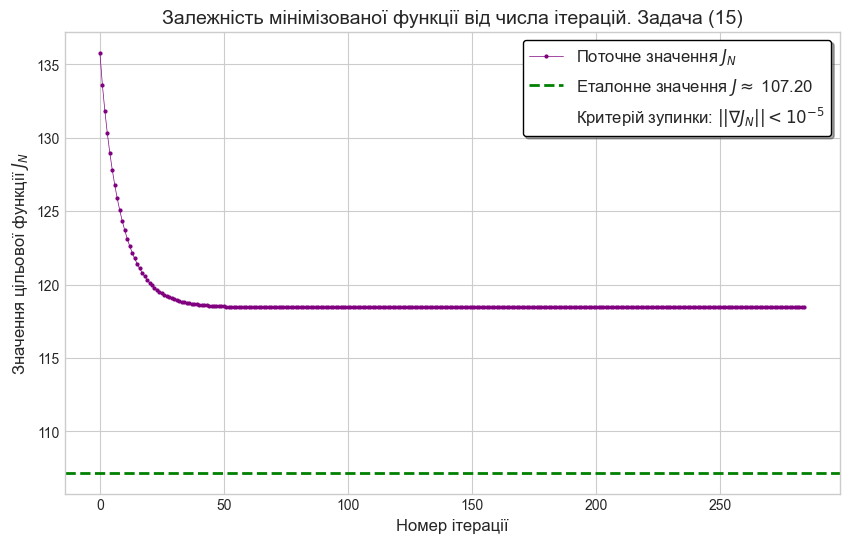

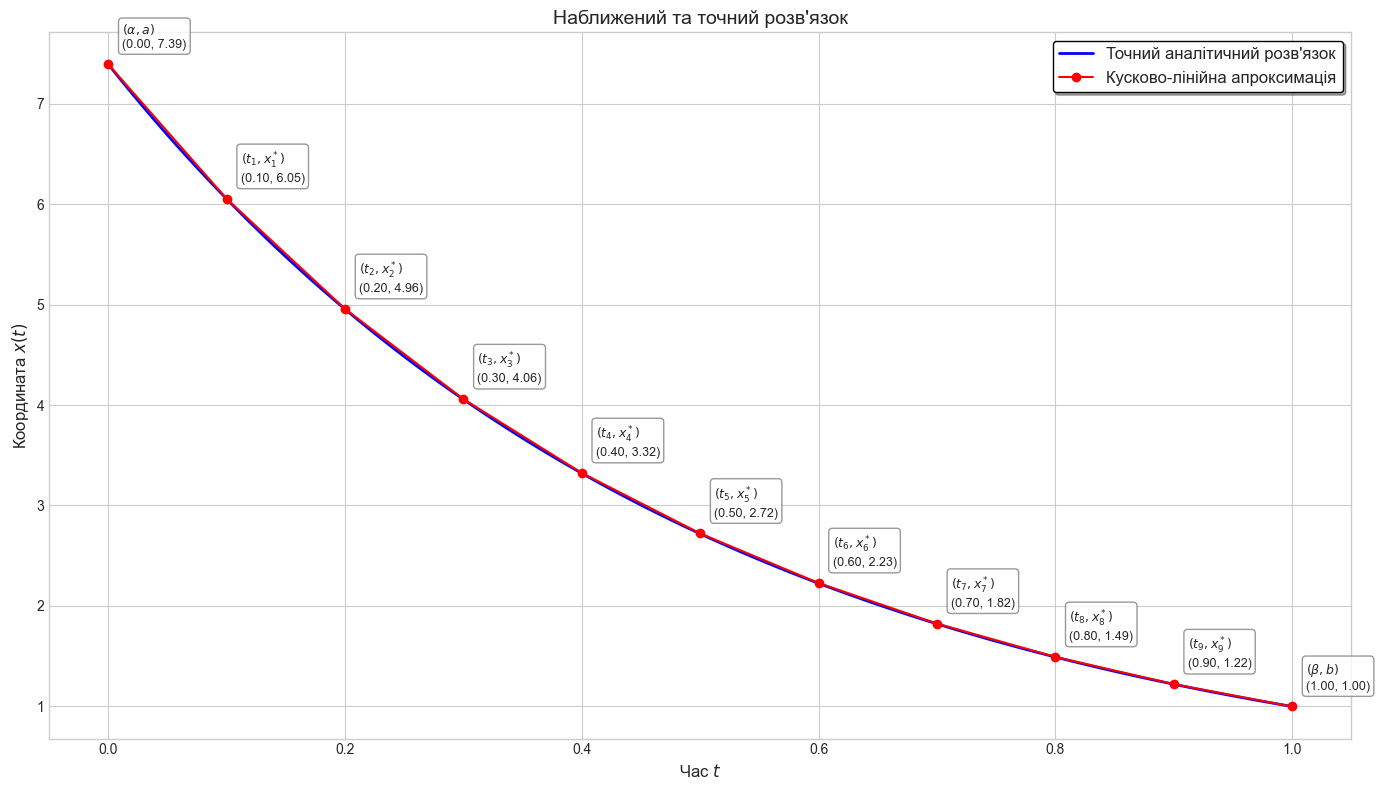

Обчислення похибок для різних N...
Оптимізацію завершено на ітерації: 163
Оптимізацію завершено на ітерації: 639
Оптимізацію завершено на ітерації: 992
Оптимізацію завершено на ітерації: 5997


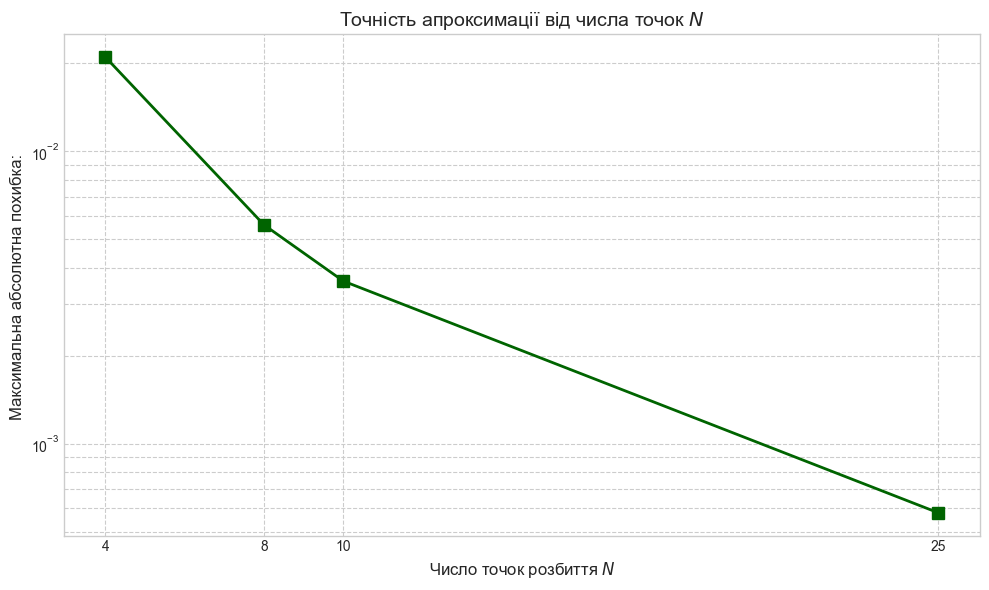

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Вхідні дані задачі (15)
# J(x) = \int_0^1 ((x')^2 + 4x^2) dt -> min
alpha, beta = 0.0, 1.0
a, b = np.exp(2), 1.0

N_points = 10
dt = (beta - alpha) / N_points
safe_gamma = 0.2 * dt
exact_J_val = 2 * (np.exp(4) - 1)
epsilon_stop = 1e-5

# Функції, що описують підінтегральний вираз I(t, x, x') та його частинні похідні
def I_func(x, x_dot):
    return x_dot**2 + 4 * x**2

def dI_dx(x):
    return 8 * x

def dI_dxdot(x_dot):
    return 2 * x_dot

def exact_solution(t):
    return np.exp(2 - 2*t)

# Апроксимація інтегралу, похідні та регуляризація
def calculate_J_N(X, N, lambda_reg=0.0):

    dt = (beta - alpha) / N
    
    # Повний вектор x з урахуванням граничних умов
    x_full = np.zeros(N + 1)
    x_full[0], x_full[-1] = a, b
    x_full[1:-1] = X
    
    J_val = 0.0
    
    # Метод лівих прямокутників (сума від i=0 до N-1)
    for i in range(N):
        x_i = x_full[i]
        x_next = x_full[i+1]
        
        # Перша похідна для апроксимації
        x_dot_i = (x_next - x_i) / dt
        
        # Основний підінтегральний вираз
        I_val = I_func(x_i, x_dot_i)
        
        # Регуляризація
        reg_val = lambda_reg * (x_dot_i)**2
        
        # Накопичення суми
        J_val += (I_val + reg_val) * dt
        
    return J_val

# Метод градієнтного спуску
def calculate_gradient(X, N, lambda_reg=0.0):

    dt = (beta - alpha) / N
    grad = np.zeros(N - 1)
    
    x_full = np.zeros(N + 1)
    x_full[0], x_full[-1] = a, b
    x_full[1:-1] = X
    
    # Проходимо по внутр. точках
    for i_full in range(1, N):
        i_grad = i_full - 1
        
        x_prev = x_full[i_full - 1]
        x_curr = x_full[i_full]
        x_next = x_full[i_full + 1]
        
        # Апроксимація похідних для сусідніх відрізків
        x_dot_prev = (x_curr - x_prev) / dt # для t_{i-1}
        x_dot_curr = (x_next - x_curr) / dt # для t_i
        
        # Обчислення частинних похідних I(t, x, x')
        dI_dxdot_prev = dI_dxdot(x_dot_prev)
        dI_dx_curr = dI_dx(x_curr)
        dI_dxdot_curr = dI_dxdot(x_dot_curr)
        
        grad_val = (dI_dxdot_prev * (1/dt) + dI_dx_curr - dI_dxdot_curr * (1/dt)) * dt
        
        # Похідна від компоненти регуляризації
        if lambda_reg > 0:
            reg_grad = (2 * lambda_reg / dt) * (x_curr - x_prev) - \
                       (2 * lambda_reg / dt) * (x_next - x_curr)
            grad_val += reg_grad
            
        grad[i_grad] = grad_val
        
    return grad

def manual_gradient_descent(N, max_iter=10000, gamma=safe_gamma, epsilon=1e-5, lambda_reg=0.0):

    # Початкове наближення
    X = np.linspace(a, b, N + 1)[1:-1]
    
    history_J = []
    
    for iteration in range(max_iter):
        J_current = calculate_J_N(X, N, lambda_reg)
        history_J.append(J_current)
        
        # Обчислюємо градієнт
        grad = calculate_gradient(X, N, lambda_reg)
        
        # Критерій зупинки: норма градієнта стала меншою за задану точність
        if np.linalg.norm(grad) < epsilon:
            print(f"Оптимізацію завершено на ітерації: {iteration}")
            break
            
        # Крок
        X = X - gamma * grad
        
    return X, history_J

X_opt, history = manual_gradient_descent(N=N_points, max_iter=5000, gamma=safe_gamma, epsilon=1e-6, lambda_reg=0.0)

# Графік збіжності
def plot_con():
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(history)), history, color='purple', 
            marker='.', markersize=4, linestyle='-', linewidth=0.5, 
            label='Поточне значення $J_N$')
    # Еталонне значення мінімізованої функції
    plt.axhline(exact_J_val, color='green', linestyle='--', linewidth=2, 
                label=f'Еталонне значення $J \\approx$ {exact_J_val:.2f}')
    stop_criterion_label = 'Критерій зупинки: $||\\nabla J_N|| < 10^{{-5}}$'
    plt.plot([], [], ' ', label=stop_criterion_label)
    plt.title('Залежність мінімізованої функції від числа ітерацій. Задача (15)', fontsize=14)
    plt.xlabel('Номер ітерації', fontsize=12)
    plt.ylabel('Значення цільової функції $J_N$', fontsize=12)
    plt.legend(fontsize=12, loc='best', frameon=True, edgecolor='black', shadow=True)
    plt.grid(True)
    plt.show()

# Кусково-лінійна функція та точний розв'язок
def plot_approximation(t_grid, x_opt_full, t_dense, x_exact_dense):
    plt.figure(figsize=(14, 8))
    # Точний розв'язок
    plt.plot(t_dense, x_exact_dense, label="Точний аналітичний розв'язок", color='blue', linewidth=2)
    # Кусково-лінійна апроксимація
    plt.plot(t_grid, x_opt_full, label='Кусково-лінійна апроксимація', color='red', marker='o', linestyle='-')

    # Підписи над кожною точкою
    for i in range(len(t_grid)):
        t_val = t_grid[i]
        x_val = x_opt_full[i]
        if i == 0:
            point_name = r"(\alpha, a)"
        elif i == len(t_grid) - 1:
            point_name = r"(\beta, b)"
        else:
            point_name = f"(t_{{{i}}}, x^*_{{{i}}})"
            
        label_text = f"${point_name}$\n({t_val:.2f}, {x_val:.2f})"
        
        plt.annotate(
            label_text, xy=(t_val, x_val), xytext=(10, 10), textcoords='offset points',
            ha='left', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8)
        )

    plt.title("Наближений та точний розв'язок", fontsize=14)
    plt.xlabel('Час $t$', fontsize=12)
    plt.ylabel('Координата $x(t)$', fontsize=12)
    plt.legend(fontsize=12, loc='upper right', frameon=True, edgecolor='black', shadow=True)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Залежність похибки від розмірності сітки N
def plot_error_analysis(N_values, errors):
    plt.figure(figsize=(10, 6))
    plt.plot(N_values, errors, marker='s', color='darkgreen', markersize=8, linewidth=2)
    
    plt.title('Точність апроксимації від числа точок $N$', fontsize=14)
    plt.xlabel('Число точок розбиття $N$', fontsize=12)
    plt.ylabel('Максимальна абсолютна похибка: ', fontsize=12)
    
    plt.yscale('log') 
    plt.xticks(N_values)
    plt.grid(True, which="both", ls="--")
    plt.tight_layout()
    plt.show()

# Графік збіжності
plot_con()

# Графік кусково-лінійної функції
t_grid = np.linspace(alpha, beta, N_points + 1)
x_opt_full = np.concatenate(([a], X_opt, [b]))
t_dense = np.linspace(alpha, beta, 100)
x_exact_dense = exact_solution(t_dense)

plot_approximation(t_grid, x_opt_full, t_dense, x_exact_dense)

# Графік похибок
N_values_test = [4, 8, 10, 25]
errors = []

print("Обчислення похибок для різних N...")
for n_test in N_values_test:
    dt_test = (beta - alpha) / n_test
    gamma_test = 0.05 * dt_test
    x_opt_n, _ = manual_gradient_descent(N=n_test, max_iter=50000, gamma=gamma_test, epsilon=epsilon_stop)
    x_full_n = np.concatenate(([a], x_opt_n, [b]))
    t_grid_n = np.linspace(alpha, beta, n_test + 1)
    exact_n = exact_solution(t_grid_n)
    max_error = np.max(np.abs(x_full_n - exact_n))
    errors.append(max_error)

plot_error_analysis(N_values_test, errors)

### Задача 23 аналітичний розв'язок

Відшукати екстремалі функціонала:
$$J(x_1(\cdot), x_2(\cdot)) = \int_{0}^{1} \left( (x_1^{\prime})^2 + (x_2^{\prime})^2 - 2x_1 x_2 \right) dt \rightarrow \operatorname{extr}$$
$$x_1(0) = 0, \quad x_1(1) = \operatorname{sh} 1$$
$$x_2(0) = 0, \quad x_2(1) = -\operatorname{sh} 1$$

Згідно з Теоремою 5.2 має виконуватись система диференціальних рівнянь Ейлера:
$$\begin{cases} 
L_{x_1} - \frac{d}{dt} L_{x_1'} = 0 \\ 
L_{x_2} - \frac{d}{dt} L_{x_2'} = 0 
\end{cases}$$

Визначаємо підінтегральну функцію:
$$L(t, x_1, x_2, x_1^{\prime}, x_2^{\prime}) = (x_1^{\prime})^2 + (x_2^{\prime})^2 - 2x_1 x_2$$

Для першого рівняння $x_1$:
* $L_{x_1} = -2x_2$
* $L_{x_1'} = 2x_1'$
* $\frac{d}{dt} L_{x_1'} = 2x_1^{\prime\prime}$

Для другого рівняння $x_2$:
* $L_{x_2} = -2x_1$
* $L_{x_2'} = 2x_2'$
* $\frac{d}{dt} L_{x_2'} = 2x_2^{\prime\prime}$

Підставляємо знайдені похідні у систему рівнянь:
$$\begin{cases} -2x_2 - 2x_1^{\prime\prime} = 0 \\ -2x_1 - 2x_2^{\prime\prime} = 0 \end{cases}$$

Поділимо обидва рівняння на $-2$ і виразимо похідні:
$$\begin{cases} x_1^{\prime\prime} = -x_2 \\ x_2^{\prime\prime} = -x_1 \end{cases}$$

Щоб розв'язати систему, продиференціюємо перше рівняння двічі по $t$:
$$(x_1^{\prime\prime})^{\prime\prime} = (-x_2)^{\prime\prime} \implies x_1^{(4)} = -x_2^{\prime\prime}$$

Підставляємо замість $x_2^{\prime\prime}$ його значення з другого рівняння:
$$x_1^{(4)} = -(-x_1) \implies x_1^{(4)} - x_1 = 0$$

Складаємо характеристичне рівняння: 
$$\lambda^4 - 1 = 0 \implies (\lambda^2 - 1)(\lambda^2 + 1) = 0$$
Корені: $\lambda_{1,2} = \pm 1$, $\lambda_{3,4} = \pm i$.
Записуємо загальний розв'язок для $x_1(t)$ через гіперболічні та тригонометричні функції:
$$x_1(t) = A \operatorname{ch} t + B \operatorname{sh} t + C \cos t + D \sin t$$

Для знаходження $x_2(t)$ використовуємо залежність $x_2 = -x_1^{\prime\prime}$. Двічі диференціюємо $x_1(t)$:
$$x_1^{\prime\prime}(t) = A \operatorname{ch} t + B \operatorname{sh} t - C \cos t - D \sin t$$

Загальний розв'язок системи має вигляд:
$$\begin{cases} 
x_1(t) = A \operatorname{ch} t + B \operatorname{sh} t + C \cos t + D \sin t \\
x_2(t) = -A \operatorname{ch} t - B \operatorname{sh} t + C \cos t + D \sin t 
\end{cases}$$

Підставляємо задані граничні умови для знаходження констант $A, B, C, D$.

1) Умови на лівому кінці відрізка ($t=0$):
$$\begin{cases} x_1(0) = A + C = 0 \\ x_2(0) = -A + C = 0 \end{cases}$$

Додавши ці рівняння, отримаємо $2C = 0 \implies \mathbf{C = 0}$.
З першого рівняння отримуємо $\mathbf{A = 0}$.
Отже, система загального розв'язку спрощується:
$$x_1(t) = B \operatorname{sh} t + D \sin t$$
$$x_2(t) = -B \operatorname{sh} t + D \sin t$$

2) Умови на правому кінці відрізка ($t=1$):
$$\begin{cases} 
x_1(1) = B \operatorname{sh} 1 + D \sin 1 = \operatorname{sh} 1 \\ 
x_2(1) = -B \operatorname{sh} 1 + D \sin 1 = -\operatorname{sh} 1 
\end{cases}$$

Складаємо ці два рівняння разом:
$$2D \sin 1 = 0 \implies \mathbf{D = 0}$$

Віднімаємо друге рівняння від першого:
$$2B \operatorname{sh} 1 = 2\operatorname{sh} 1 \implies \mathbf{B = 1}$$

Підставляємо знайдені константи ($A=0, B=1, C=0, D=0$) у спрощений загальний розв'язок.

Відповідь:
$$x_1(t) = \operatorname{sh} t$$
$$x_2(t) = -\operatorname{sh} t$$

### Задача 23. Чисельний розв'язок з градієнтним методом мінімізації

Зупинка на ітерації: 992 (N=10)


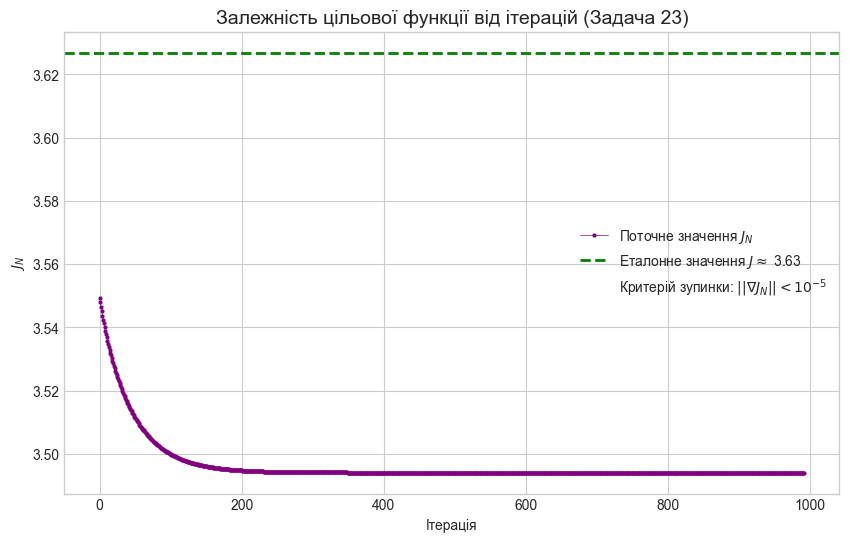

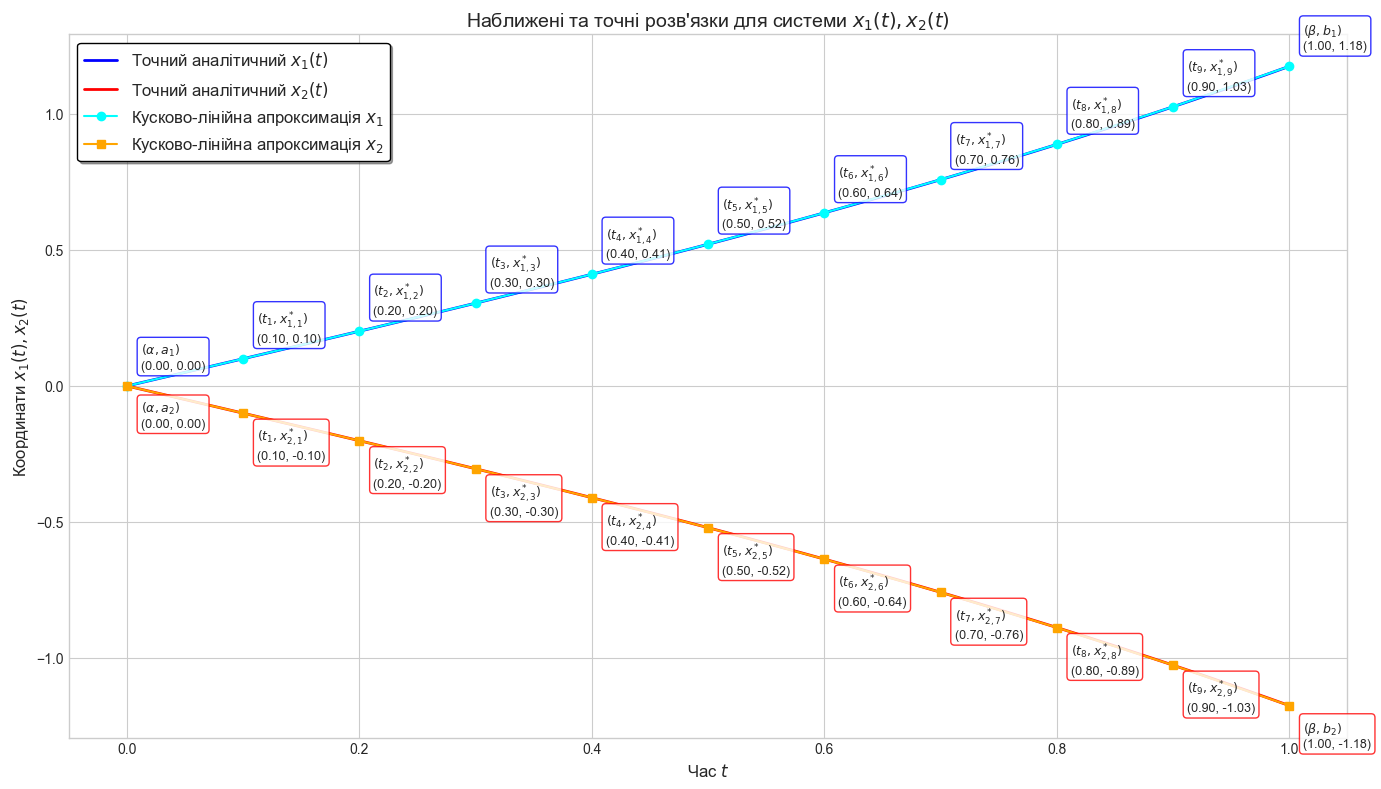

Обчислення похибок для різних N...
Зупинка на ітерації: 167 (N=4)
N = 4 обчислено. Максимальна похибка: 0.00031
Зупинка на ітерації: 642 (N=8)
N = 8 обчислено. Максимальна похибка: 0.00008
Зупинка на ітерації: 1416 (N=12)
N = 12 обчислено. Максимальна похибка: 0.00004
Зупинка на ітерації: 2482 (N=16)
N = 16 обчислено. Максимальна похибка: 0.00002
Зупинка на ітерації: 3836 (N=20)
N = 20 обчислено. Максимальна похибка: 0.00001


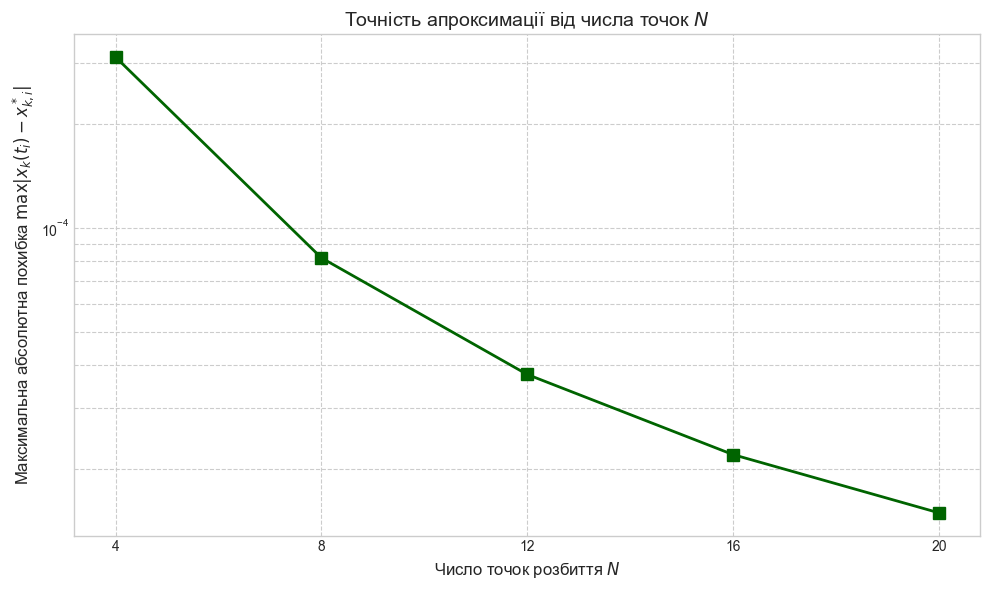

In [24]:
import numpy as np
import matplotlib.pyplot as plt

alpha, beta = 0.0, 1.0

# Граничні умови для x1 та x2
a1, b1 = 0.0, np.sinh(1.0)
a2, b2 = 0.0, -np.sinh(1.0)

N_points = 10
dt_main = (beta - alpha) / N_points
epsilon_stop = 1e-5
lambda_reg_val = 0.0 

# Точні аналітичні розв'язки
def exact_solution_x1(t): return np.sinh(t)
def exact_solution_x2(t): return -np.sinh(t)

# Еталонне значення для задачі 23
exact_J_val = np.sinh(2)

# I(t, x1, x2, x1', x2') = (x1')^2 + (x2')^2 - 2*x1*x2
def I_func(x1, x2, x1_dot, x2_dot):
    return x1_dot**2 + x2_dot**2 - 2 * x1 * x2

def dI_dx1(x2): return -2 * x2
def dI_dx2(x1): return -2 * x1
def dI_dx1dot(x1_dot): return 2 * x1_dot
def dI_dx2dot(x2_dot): return 2 * x2_dot

def calculate_J_N(X, N, lambda_reg=0.0):
    dt = (beta - alpha) / N
    X1, X2 = X[:N-1], X[N-1:]
    
    x1_full = np.concatenate(([a1], X1, [b1]))
    x2_full = np.concatenate(([a2], X2, [b2]))
    
    J_val = 0.0
    for i in range(N):
        x1_i, x2_i = x1_full[i], x2_full[i]
        x1_dot_i = (x1_full[i+1] - x1_i) / dt
        x2_dot_i = (x2_full[i+1] - x2_i) / dt
        
        I_val = I_func(x1_i, x2_i, x1_dot_i, x2_dot_i)
        reg_val = lambda_reg * (x1_dot_i**2 + x2_dot_i**2)
        
        J_val += (I_val + reg_val) * dt
    return J_val

def calculate_gradient(X, N, lambda_reg=0.0):
    dt = (beta - alpha) / N
    grad1, grad2 = np.zeros(N - 1), np.zeros(N - 1)
    
    X1, X2 = X[:N-1], X[N-1:]
    x1_full = np.concatenate(([a1], X1, [b1]))
    x2_full = np.concatenate(([a2], X2, [b2]))
    
    for i_full in range(1, N):
        i_grad = i_full - 1
        
        x1_prev, x1_curr, x1_next = x1_full[i_full-1], x1_full[i_full], x1_full[i_full+1]
        x2_prev, x2_curr, x2_next = x2_full[i_full-1], x2_full[i_full], x2_full[i_full+1]
        
        x1_dot_prev = (x1_curr - x1_prev) / dt
        x1_dot_curr = (x1_next - x1_curr) / dt
        x2_dot_prev = (x2_curr - x2_prev) / dt
        x2_dot_curr = (x2_next - x2_curr) / dt
        
        grad1_val = (dI_dx1dot(x1_dot_prev)*(1/dt) + dI_dx1(x2_curr) - dI_dx1dot(x1_dot_curr)*(1/dt)) * dt
        grad2_val = (dI_dx2dot(x2_dot_prev)*(1/dt) + dI_dx2(x1_curr) - dI_dx2dot(x2_dot_curr)*(1/dt)) * dt
        
        if lambda_reg > 0:
            grad1_val += (2 * lambda_reg / dt) * (x1_curr - x1_prev) - (2 * lambda_reg / dt) * (x1_next - x1_curr)
            grad2_val += (2 * lambda_reg / dt) * (x2_curr - x2_prev) - (2 * lambda_reg / dt) * (x2_next - x2_curr)
            
        grad1[i_grad] = grad1_val
        grad2[i_grad] = grad2_val
        
    return np.concatenate((grad1, grad2))

def manual_gradient_descent(N, max_iter=10000, gamma=0.01, epsilon=1e-5, lambda_reg=0.0):
    # Початкове наближення для двох функцій
    X1_init = np.linspace(a1, b1, N + 1)[1:-1]
    X2_init = np.linspace(a2, b2, N + 1)[1:-1]
    X = np.concatenate((X1_init, X2_init))
    
    history_J = []
    
    for iteration in range(max_iter):
        history_J.append(calculate_J_N(X, N, lambda_reg))
        grad = calculate_gradient(X, N, lambda_reg)
        
        if np.linalg.norm(grad) < epsilon:
            print(f"Зупинка на ітерації: {iteration} (N={N})")
            break
            
        X = X - gamma * grad
        
    return X, history_J

gamma_safe = 0.05 * dt_main 

X_opt_flat, history = manual_gradient_descent(
    N=N_points, 
    max_iter=30000, 
    gamma=gamma_safe, 
    epsilon=epsilon_stop, 
    lambda_reg=lambda_reg_val
)

x1_opt_inner = X_opt_flat[:N_points-1]
x2_opt_inner = X_opt_flat[N_points-1:]

x1_opt_full = np.concatenate(([a1], x1_opt_inner, [b1]))
x2_opt_full = np.concatenate(([a2], x2_opt_inner, [b2]))
t_grid = np.linspace(alpha, beta, N_points + 1)

plt.style.use('seaborn-v0_8-whitegrid')

# Графік 1: Збіжність
plt.figure(figsize=(10, 6))
plt.plot(range(len(history)), history, color='purple', marker='.', markersize=4, linewidth=0.5, label='Поточне значення $J_N$')
plt.axhline(exact_J_val, color='green', linestyle='--', linewidth=2, label=f'Еталонне значення $J \\approx$ {exact_J_val:.2f}')
plt.plot([], [], ' ', label=r'Критерій зупинки: $||\nabla J_N|| < 10^{-5}$')
plt.title('Залежність цільової функції від ітерацій (Задача 23)', fontsize=14)
plt.xlabel('Ітерація')
plt.ylabel('$J_N$')
plt.legend(loc='best')
plt.show()

# Кусково-лінійні функції та точні розв'язки
def plot_approximation(t_grid, x1_opt_full, x2_opt_full, t_dense, x1_exact_dense, x2_exact_dense):
    plt.figure(figsize=(14, 8))
    
    # Точні розв'язки
    plt.plot(t_dense, x1_exact_dense, label="Точний аналітичний $x_1(t)$", color='blue', linewidth=2)
    plt.plot(t_dense, x2_exact_dense, label="Точний аналітичний $x_2(t)$", color='red', linewidth=2)
    
    # Кусково-лінійні апроксимації
    plt.plot(t_grid, x1_opt_full, label='Кусково-лінійна апроксимація $x_1$', color='cyan', marker='o', linestyle='-')
    plt.plot(t_grid, x2_opt_full, label='Кусково-лінійна апроксимація $x_2$', color='orange', marker='s', linestyle='-')

    for i in range(len(t_grid)):
        t_val = t_grid[i]
        x1_val = x1_opt_full[i]
        x2_val = x2_opt_full[i]
        
        if i == 0:
            point_name_1 = r"(\alpha, a_1)"
        elif i == len(t_grid) - 1:
            point_name_1 = r"(\beta, b_1)"
        else:
            point_name_1 = f"(t_{{{i}}}, x_{{1,{i}}}^*)"
            
        if i == 0:
            point_name_2 = r"(\alpha, a_2)"
        elif i == len(t_grid) - 1:
            point_name_2 = r"(\beta, b_2)"
        else:
            point_name_2 = f"(t_{{{i}}}, x_{{2,{i}}}^*)"
            
        label_text_1 = f"${point_name_1}$\n({t_val:.2f}, {x1_val:.2f})"
        label_text_2 = f"${point_name_2}$\n({t_val:.2f}, {x2_val:.2f})"
        
        # Анотація для x1
        plt.annotate(
            label_text_1, xy=(t_val, x1_val), xytext=(10, 10), textcoords='offset points',
            ha='left', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='blue', alpha=0.8)
        )
        
        # Анотація для x2
        plt.annotate(
            label_text_2, xy=(t_val, x2_val), xytext=(10, -10), textcoords='offset points',
            ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.8)
        )

    plt.title("Наближені та точні розв'язки для системи $x_1(t), x_2(t)$", fontsize=14)
    plt.xlabel('Час $t$', fontsize=12)
    plt.ylabel('Координати $x_1(t), x_2(t)$', fontsize=12)
    
    plt.legend(fontsize=12, loc='best', frameon=True, edgecolor='black', shadow=True)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Підготовка сітки часу
t_grid = np.linspace(alpha, beta, N_points + 1)
t_dense = np.linspace(alpha, beta, 100)

# Розпакування внутрішніх точок
x1_opt_inner = X_opt_flat[:N_points-1]
x2_opt_inner = X_opt_flat[N_points-1:]

# Додавання граничних умов (a1, b1 для x1; a2, b2 для x2)
x1_opt_full = np.concatenate(([a1], x1_opt_inner, [b1]))
x2_opt_full = np.concatenate(([a2], x2_opt_inner, [b2]))

# Обчислення точних розв'язків на густій сітці
x1_exact_dense = exact_solution_x1(t_dense)
x2_exact_dense = exact_solution_x2(t_dense)

plot_approximation(t_grid, x1_opt_full, x2_opt_full, t_dense, x1_exact_dense, x2_exact_dense)

N_values_test = [4, 8, 12, 16, 20]
errors = []

print("Обчислення похибок для різних N...")

for n_test in N_values_test:
    dt_test = (beta - alpha) / n_test
    gamma_test = 0.05 * dt_test 
    
    x_opt_n_flat, _ = manual_gradient_descent(
        N=n_test, 
        max_iter=80000, 
        gamma=gamma_test, 
        epsilon=epsilon_stop, 
        lambda_reg=lambda_reg_val
    )
    
    x1_opt_n = x_opt_n_flat[:n_test-1]
    x2_opt_n = x_opt_n_flat[n_test-1:]
    
    x1_full_n = np.concatenate(([a1], x1_opt_n, [b1]))
    x2_full_n = np.concatenate(([a2], x2_opt_n, [b2]))
    
    t_grid_n = np.linspace(alpha, beta, n_test + 1)
    
    exact_x1_n = exact_solution_x1(t_grid_n)
    exact_x2_n = exact_solution_x2(t_grid_n)
    
    max_err_x1 = np.max(np.abs(x1_full_n - exact_x1_n))
    max_err_x2 = np.max(np.abs(x2_full_n - exact_x2_n))
    max_error = max(max_err_x1, max_err_x2)
    
    errors.append(max_error)
    print(f"N = {n_test} обчислено. Максимальна похибка: {max_error:.5f}")

plt.figure(figsize=(10, 6))
plt.plot(N_values_test, errors, marker='s', color='darkgreen', markersize=8, linewidth=2)

plt.title('Точність апроксимації від числа точок $N$', fontsize=14)
plt.xlabel('Число точок розбиття $N$', fontsize=12)
plt.ylabel(r'Максимальна абсолютна похибка $\max |x_k(t_i) - x^*_{k,i}|$', fontsize=12)

plt.yscale('log') 
plt.xticks(N_values_test)
plt.grid(True, which="both", ls="--")
plt.tight_layout()

plt.show()